<a href="https://colab.research.google.com/github/Ahmedgamale/Industrial-Inspection-Robot/blob/main/notebooks/spectral_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_excel('/content/Apple_Plastic_Defect_Dataset.xlsx')
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Material     500 non-null    object 
 1   R_mean       500 non-null    float64
 2   G_mean       500 non-null    float64
 3   B_mean       500 non-null    float64
 4   Texture      500 non-null    float64
 5   EdgeDensity  500 non-null    float64
 6   Label        500 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 27.5+ KB


,Material,R_mean,G_mean,B_mean,Texture,EdgeDensity,Label
0,Apple,144.363503,144.014286,129.639879,0.909866,0.115602,0
1,Apple,138.899863,126.161672,132.323523,0.910112,0.170807,0
2,Apple,135.514612,144.398197,131.648853,0.871234,0.118182,0
3,Apple,139.585113,131.084845,125.495129,0.893195,0.129123,0
4,Apple,150.296322,127.789877,120.842893,0.886636,0.145607,0


Label
0    250
1    250
Name: count, dtype: int64


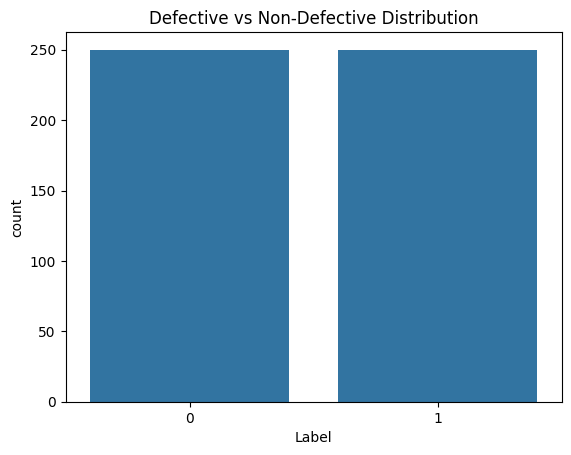

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Class distribution
print(df['Label'].value_counts())

sns.countplot(x='Label', data=df)
plt.title('Defective vs Non-Defective Distribution')
plt.show()


In [ ]:
# Features and target
X = df.drop(columns=['Label'])
y = df['Label']

# Encode categorical column
X = pd.get_dummies(X, columns=['Material'])

X.head()


,R_mean,G_mean,B_mean,Texture,EdgeDensity,Material_Apple,Material_Plastic
0,144.363503,144.014286,129.639879,0.909866,0.115602,True,False
1,138.899863,126.161672,132.323523,0.910112,0.170807,True,False
2,135.514612,144.398197,131.648853,0.871234,0.118182,True,False
3,139.585113,131.084845,125.495129,0.893195,0.129123,True,False
4,150.296322,127.789877,120.842893,0.886636,0.145607,True,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



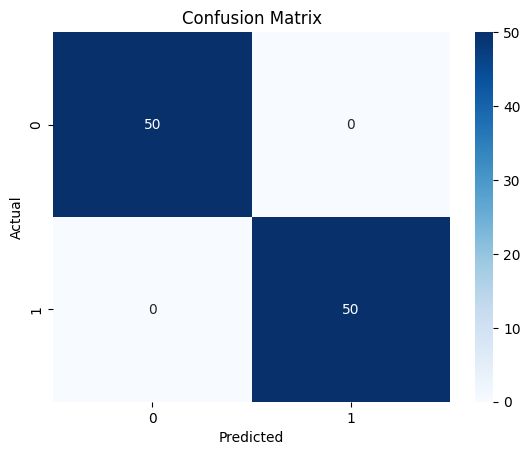

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = X.columns
importances = model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_df


,Feature,Importance
3,Texture,0.344574
4,EdgeDensity,0.340055
1,G_mean,0.105540
0,R_mean,0.095711
2,B_mean,0.095222
5,Material_Apple,0.010994
6,Material_Plastic,0.007904


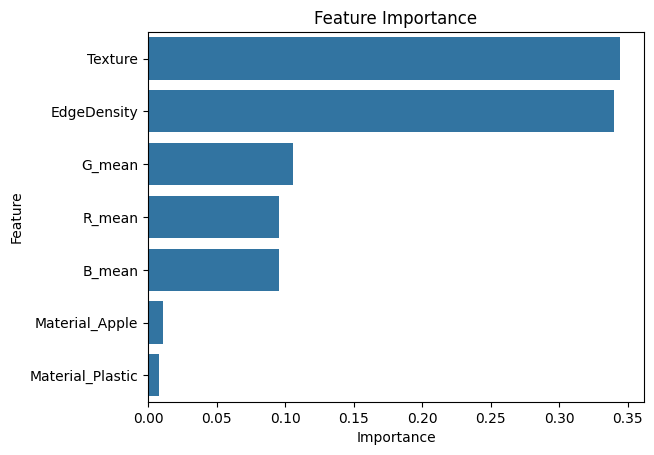

In [ ]:
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title('Feature Importance')
plt.show()
